In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("transactions.csv")

df.head()

,Transaction ID,Timestamp,Sender Name,Sender UPI ID,Receiver Name,Receiver UPI ID,Amount (INR),Status
0,4d3db980-46cd-4158-a812-dcb77055d0d2,2024-06-22 04:06:38,Tiya Mall,4161803452@okaxis,Mohanlal Golla,7776849307@okybl,3907.34,FAILED
1,099ee548-2fc1-4811-bf92-559c467ca792,2024-06-19 06:04:49,Mohanlal Bakshi,8908837379@okaxis,Mehul Sankaran,7683454560@okaxis,8404.55,SUCCESS
2,d4c05732-6b1b-4bab-90b9-efe09d252b99,2024-06-04 04:56:09,Kismat Bora,4633654150@okybl,Diya Goel,2598130823@okicici,941.88,SUCCESS
3,e8df92ee-8b04-4133-af5a-5f412180c8ab,2024-06-09 09:56:07,Ayesha Korpal,7018842771@okhdfcbank,Rhea Kothari,2246623650@okaxis,8926.00,SUCCESS
4,e7d675d3-04f1-419c-a841-7a04662560b7,2024-06-25 08:38:19,Jivin Batta,1977143985@okybl,Baiju Issac,5245672729@okybl,2800.55,SUCCESS


Dataset Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Transaction ID   1000 non-null   object 
 1   Timestamp        1000 non-null   object 
 2   Sender Name      1000 non-null   object 
 3   Sender UPI ID    1000 non-null   object 
 4   Receiver Name    1000 non-null   object 
 5   Receiver UPI ID  1000 non-null   object 
 6   Amount (INR)     1000 non-null   float64
 7   Status           1000 non-null   object 
dtypes: float64(1), object(7)
memory usage: 62.6+ KB


Total Transactions

In [4]:
total_transactions = df.shape[0]
print("Total Transactions:", total_transactions)


Total Transactions: 1000


Total Transaction Amount

In [5]:
total_amount = df[df["Status"] == "SUCCESS"]["Amount (INR)"].sum()
print("Total Transaction Amount:", total_amount)

Total Transaction Amount: 2539557.6899999995


Q) Average Transaction Amount

In [6]:
avg_amount = df[df["Status"] == "SUCCESS"]["Amount (INR)"].mean()
print("Average Transaction Amount:", avg_amount)

Average Transaction Amount: 5058.879860557768


QUESTION

Daily Transaction Trend

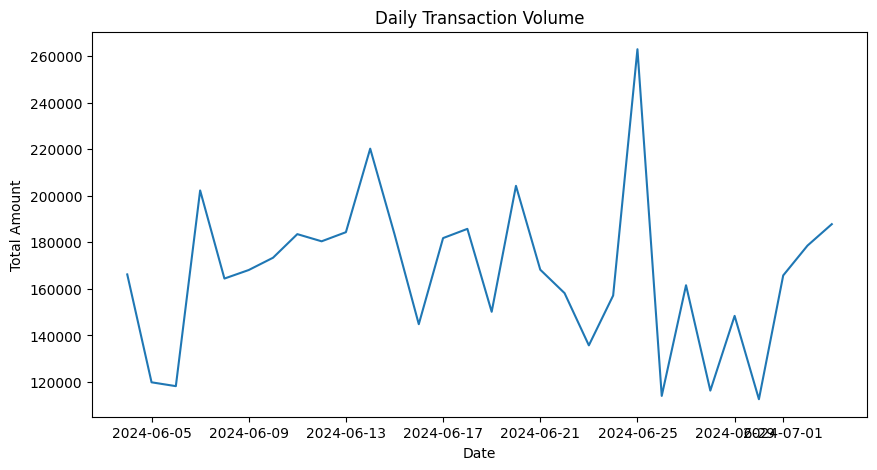

In [9]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

daily_transactions = df.groupby(df["Timestamp"].dt.date)["Amount (INR)"].sum()

daily_transactions.plot(kind="line", figsize=(10,5))
plt.title("Daily Transaction Volume")
plt.xlabel("Date")
plt.ylabel("Total Amount")
plt.show()

Transaction Status Distribution

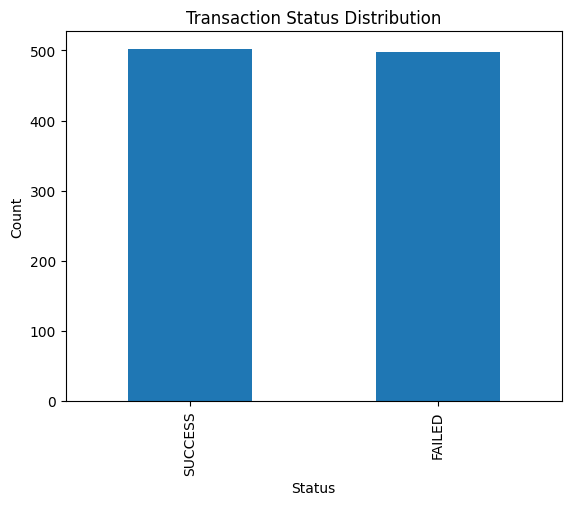

In [10]:
status_count = df["Status"].value_counts()

status_count.plot(kind="bar")
plt.title("Transaction Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

Top 10 Transactions

In [11]:
top_transactions = df.sort_values(by="Amount (INR)", ascending=False).head(10)

top_transactions[["Sender Name","Receiver Name","Amount (INR)"]]

,Sender Name,Receiver Name,Amount (INR)
484,Shlok Loke,Devansh Wagle,9993.06
442,Siya Trivedi,Mishti Chaudry,9979.32
415,Taimur Barad,Tarini Shukla,9978.85
451,Shlok Randhawa,Samar Sawhney,9958.65
561,Alisha Kurian,Tara Dayal,9952.14
370,Sana Bath,Charvi Chawla,9946.74
564,Ishaan Shere,Tara Anand,9917.23
881,Divij Sandal,Parinaaz Acharya,9916.43
980,Ryan Setty,Heer Reddy,9915.11
772,Baiju Hayre,Ranbir Iyengar,9914.17


Hourly Transaction Pattern

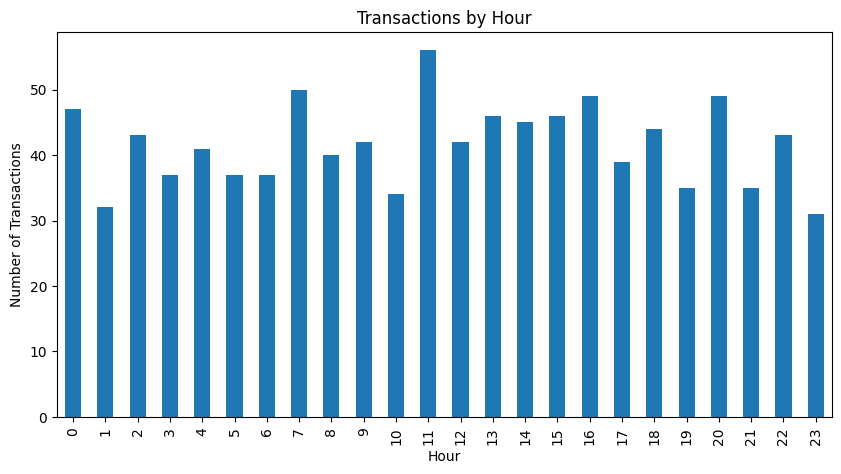

In [12]:
df["Hour"] = df["Timestamp"].dt.hour

hourly_transactions = df.groupby("Hour").size()

hourly_transactions.plot(kind="bar", figsize=(10,5))
plt.title("Transactions by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Transactions")
plt.show()

Check Missing Values

In [13]:
df.isnull().sum()

Transaction ID     0
Timestamp          0
Sender Name        0
Sender UPI ID      0
Receiver Name      0
Receiver UPI ID    0
Amount (INR)       0
Status             0
Hour               0
dtype: int64

Transaction Amount Distribution










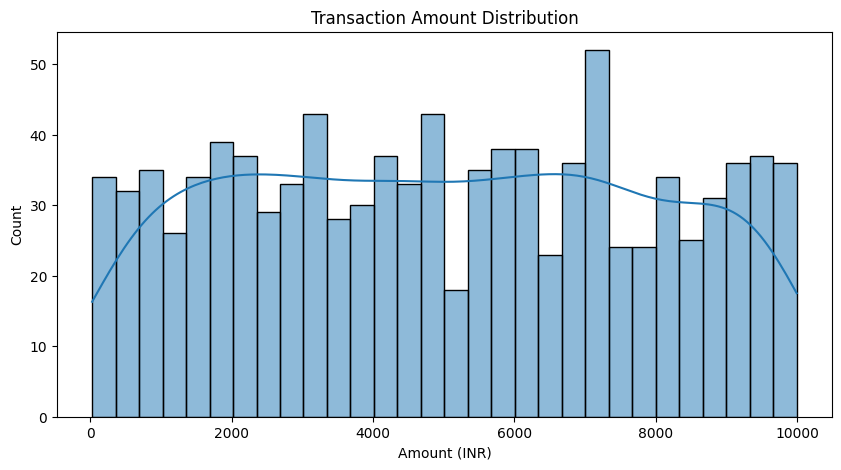

In [14]:
plt.figure(figsize=(10,5))
sns.histplot(df["Amount (INR)"], bins=30, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

High Value Transactions

In [17]:
high_value = df[df["Amount (INR)"] > 5000]

high_value[["Sender Name","Receiver Name","Amount (INR)"]].head()

,Sender Name,Receiver Name,Amount (INR)
1,Mohanlal Bakshi,Mehul Sankaran,8404.55
3,Ayesha Korpal,Rhea Kothari,8926.00
9,Rasha Das,Advik Mahal,6248.55
11,Raghav Sridhar,Shayak Jain,5465.41
12,Nirvaan Zachariah,Ranbir Shukla,5858.65


Most Frequent Sender-Receiver Pairs|

In [18]:
pairs = df.groupby(["Sender Name","Receiver Name"]).size().sort_values(ascending=False).head(10)

print(pairs)

Sender Name            Receiver Name 
Aaina Andra            Ishaan Krishna    1
Ranbir Mahajan         Dhruv Kala        1
Priyansh Venkataraman  Zara Luthra       1
Priyansh Verma         Onkar Chaudhry    1
Priyansh Yohannan      Samar Sagar       1
Purab Din              Rati Kapadia      1
Purab Jhaveri          Nayantara Kibe    1
Purab Ramaswamy        Drishya Karan     1
Purab Sibal            Lakshit Bajaj     1
Raghav Rajagopal       Shlok Arya        1
dtype: int64


Peak Transaction Days

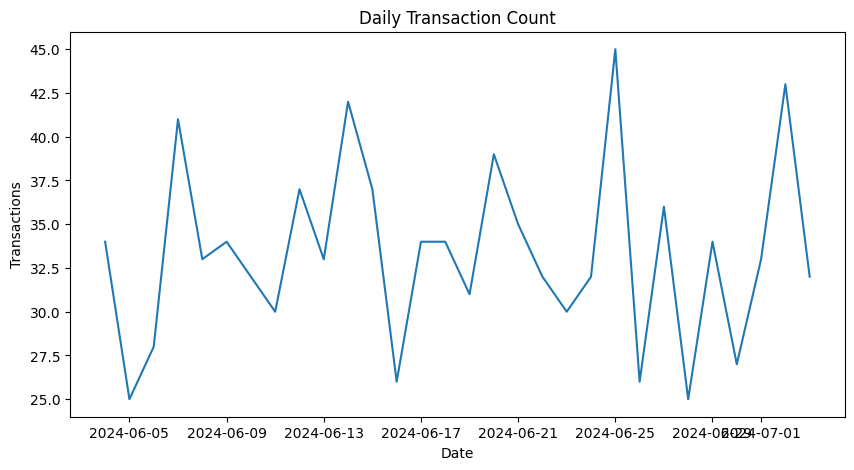

In [19]:
daily_counts = df.groupby(df["Timestamp"].dt.date).size()

daily_counts.plot(figsize=(10,5))
plt.title("Daily Transaction Count")
plt.xlabel("Date")
plt.ylabel("Transactions")
plt.show()

In [20]:
## Average Transaction per User
user_avg = df.groupby("Sender Name")["Amount (INR)"].mean().sort_values(ascending=False)

print(user_avg.head(10))

Sender Name
Shlok Loke        9993.06
Siya Trivedi      9979.32
Taimur Barad      9978.85
Shlok Randhawa    9958.65
Alisha Kurian     9952.14
Sana Bath         9946.74
Ishaan Shere      9917.23
Divij Sandal      9916.43
Ryan Setty        9915.11
Baiju Hayre       9914.17
Name: Amount (INR), dtype: float64


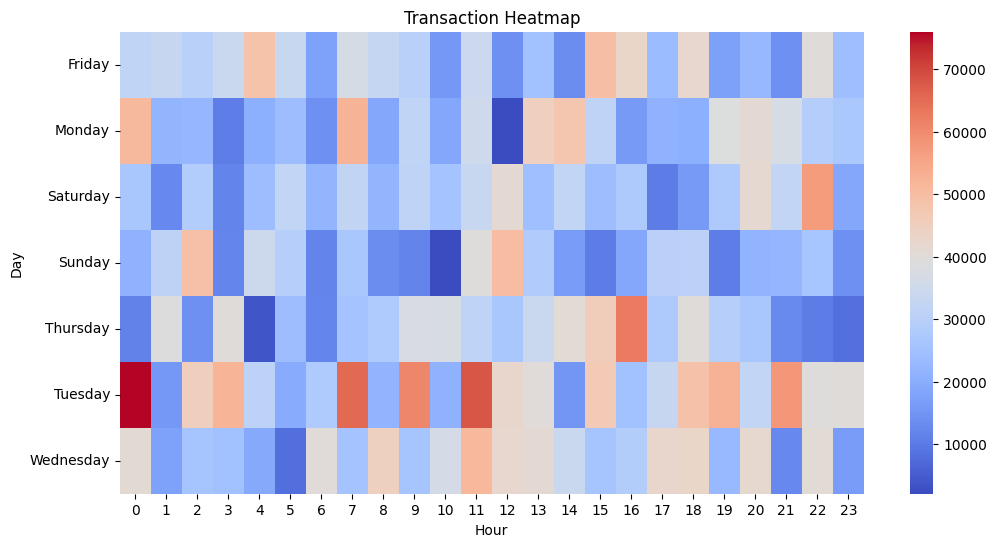

In [21]:
##Transaction Heatmap (Advanced Visualization)
df["Day"] = df["Timestamp"].dt.day_name()

pivot = pd.pivot_table(df, values="Amount (INR)", index="Day", columns="Hour", aggfunc="sum")

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="coolwarm")
plt.title("Transaction Heatmap")
plt.show()